In [84]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.ensemble import AdaBoostClassifier
from mlxtend.plotting import plot_decision_regions
warnings.filterwarnings("ignore", category=FutureWarning)
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

In [58]:
np.random.seed(42)
X, y = make_circles(n_samples=500, factor=0.1, noise=0.35, random_state=42)

In [59]:
print(f'X:{X.shape}\ny:{y.shape}')

X:(500, 2)
y:(500,)


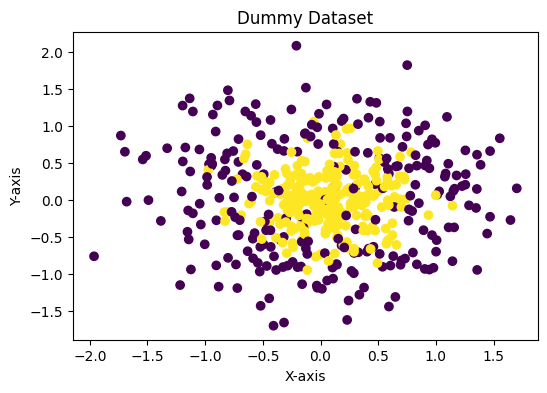

In [60]:
plt.figure(figsize=(6, 4))
plt.scatter(X[:,0], X[:,1], c=y)
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Dummy Dataset')
plt.show()

In [62]:
abc = AdaBoostClassifier()
abc.fit(X, y)

AdaBoostClassifier()

In [69]:
np.mean(cross_val_score(abc, X, y, scoring='accuracy', n_jobs=-1, cv=10))

np.float64(0.812)

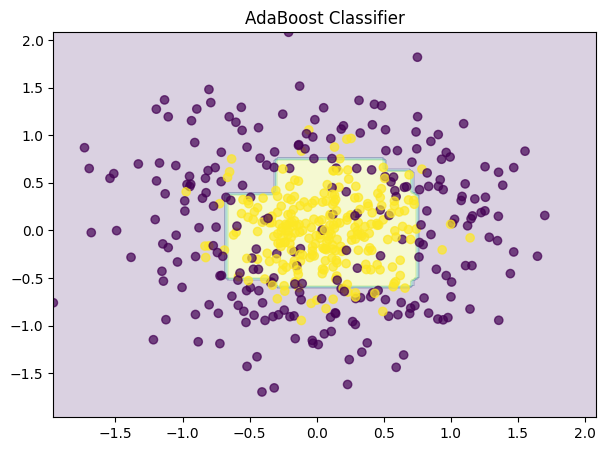

In [77]:
def plot_decision_boundary(clf):
    plt.figure(figsize=(7, 5))
    x_range = np.linspace(X.min(), X.max(), 100)
    xx1, xx2 = np.meshgrid(x_range, x_range)
    y_hat = clf.predict(np.c_[xx1.ravel(), xx2.ravel()])
    y_hat = y_hat.reshape(xx1.shape)
    plt.contourf(xx1, xx2, y_hat, alpha=0.2)
    plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=0.7)
    plt.title('AdaBoost Classifier')
    plt.show()
plot_decision_boundary(abc)

#### Hyperparameter Tunning 

In [78]:
abc_tunned = AdaBoostClassifier(n_estimators=1500, learning_rate=0.1)
abc_tunned.fit(X, y)

AdaBoostClassifier(learning_rate=0.1, n_estimators=1500)

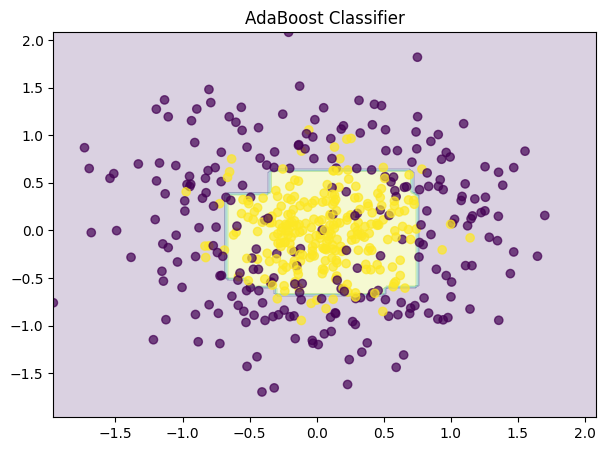

In [79]:
plot_decision_boundary(abc_tunned)

In [86]:
grid = {
    'n_estimators': [10, 50, 100, 500],
    'learning_rate': [0.0001, 0.001, 0.01, 0.1, 1.0]
}

grid_search = GridSearchCV(
    estimator=AdaBoostClassifier(),
    param_grid=grid,
    n_jobs=-1,
    cv=10,
    scoring='accuracy'
)

grid_search.fit(X, y)
print(f'Best: {grid_search.best_score_} using: {grid_search.best_estimator_}')

Best: 0.8320000000000001 using: AdaBoostClassifier(learning_rate=0.1, n_estimators=500)
